In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

#paths
PROCESSED = Path("../data/processed")
CHARTS    = Path("../reports")
CHARTS.mkdir(exist_ok=True)

#style
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["figure.dpi"]     = 100
sns.set_theme(style="whitegrid", palette="muted")

#loading all cleaned datasets
nav   = pd.read_csv(PROCESSED / "clean_nav.csv",parse_dates=["date"])
fm    = pd.read_csv(PROCESSED / "clean_fund_master.csv",parse_dates=["launch_date"])
aum   = pd.read_csv(PROCESSED / "clean_aum.csv")
sip   = pd.read_csv(PROCESSED / "clean_sip_inflows.csv")
cat   = pd.read_csv(PROCESSED / "clean_category_inflows.csv")
folio = pd.read_csv(PROCESSED / "clean_folio_count.csv")
perf  = pd.read_csv(PROCESSED / "clean_performance.csv")
tx    = pd.read_csv(PROCESSED / "clean_transactions.csv",parse_dates=["transaction_date"])
hold  = pd.read_csv(PROCESSED / "clean_portfolio_holdings.csv")
bm    = pd.read_csv(PROCESSED / "clean_benchmark_indices.csv",parse_dates=["date"])

print("All datasets are loaded ")
print(f"NAV rows      : {len(nav)}")
print(f"Transactions  : {len(tx)}")
print(f"Benchmark rows: {len(bm)}")

All datasets are loaded 
NAV rows      : 46000
Transactions  : 32778
Benchmark rows: 8050


NAV Trends 

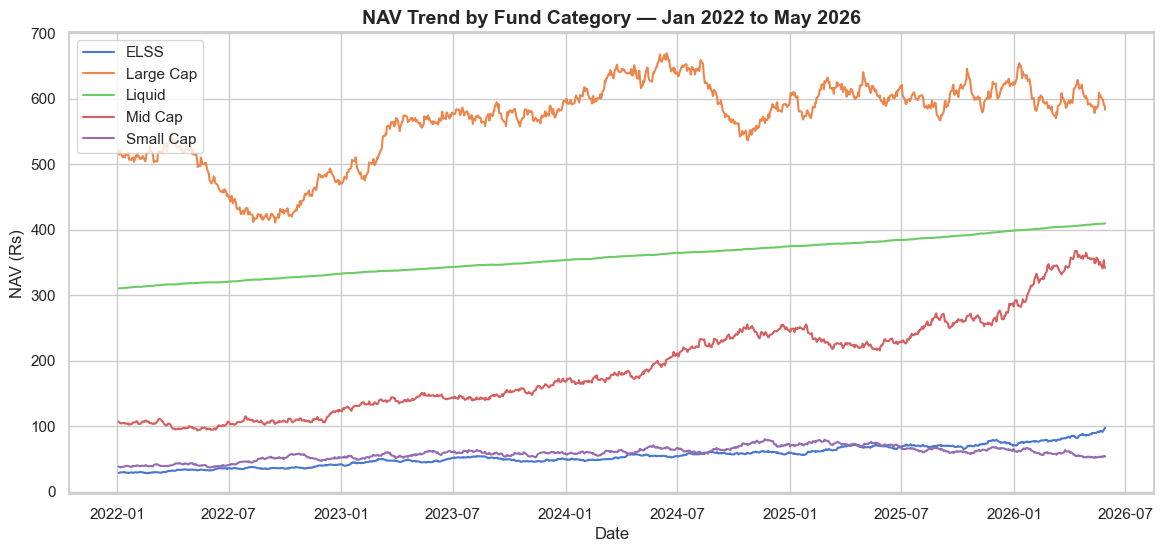

In [7]:
#merging nav with fund master to get scheme names
nav_merged = nav.merge(fm[["amfi_code","scheme_name","sub_category"]], on="amfi_code", how="left")

#pick one fund per sub_category for clarity
categories_to_plot = ["Large Cap","Mid Cap","Small Cap","ELSS","Liquid"]
sample_funds = (
    nav_merged[nav_merged["sub_category"].isin(categories_to_plot)]
    .groupby("sub_category")
    .apply(lambda x: x["amfi_code"].iloc[0])
    .reset_index()
    .rename(columns={0: "amfi_code"})
)

fig, ax = plt.subplots(figsize=(14, 6))
for _, row in sample_funds.iterrows():
    data = nav_merged[nav_merged["amfi_code"] == row["amfi_code"]]
    ax.plot(data["date"], data["nav"], label=row["sub_category"], linewidth=1.5)

ax.set_title("NAV Trend by Fund Category — Jan 2022 to May 2026", fontsize=14, fontweight="bold")
ax.set_xlabel("Date")
ax.set_ylabel("NAV (Rs)")
ax.legend()
plt.savefig(CHARTS / "chart_01_nav_trends.png", dpi=150)
plt.show()


AUM Growth by Fund House (Grouped Bar)


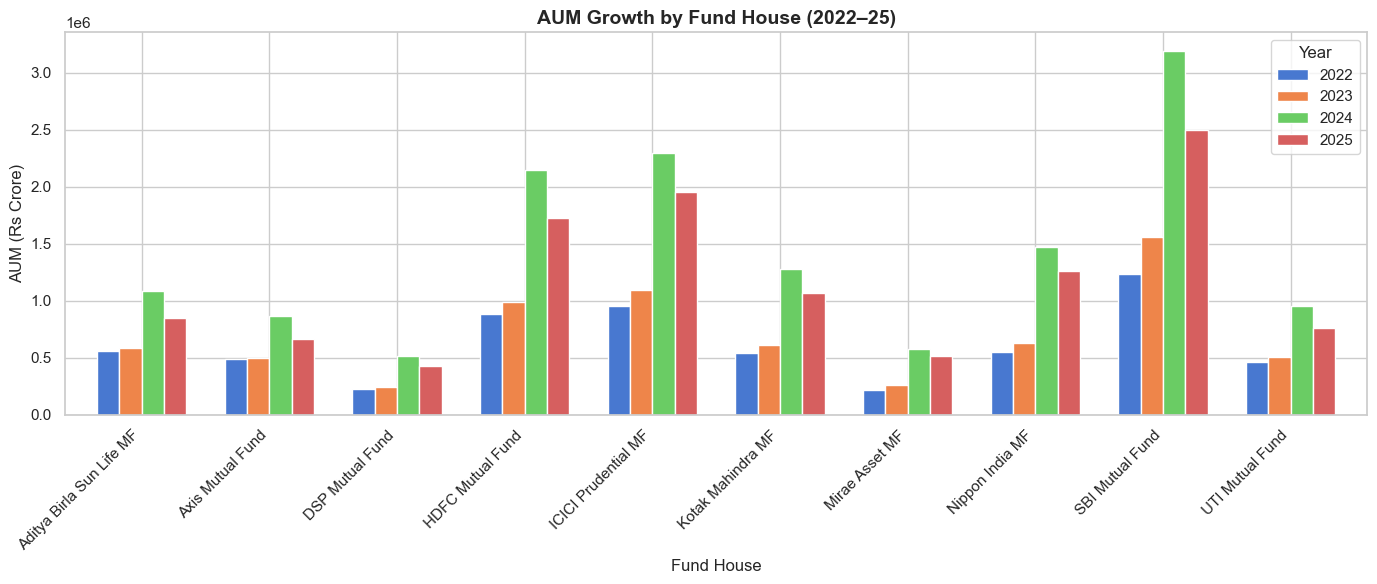

Chart 2 saved


In [14]:
aum["year"] = aum["date"].str[:4]

aum_year = aum.groupby(["fund_house","year"])["aum_crore"].sum().reset_index()
aum_pivot = aum_year.pivot(index="fund_house", columns="year", values="aum_crore")

aum_pivot.plot(kind="bar", figsize=(14, 6), width=0.7)
plt.title("AUM Growth by Fund House (2022–25)", fontsize=14, fontweight="bold")
plt.xlabel("Fund House")
plt.ylabel("AUM (Rs Crore)")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Year")
plt.tight_layout()
plt.savefig(CHARTS / "chart_02_aum_growth.png", dpi=150)
plt.show()
print("Chart 2 saved")

SIP inflow time rates

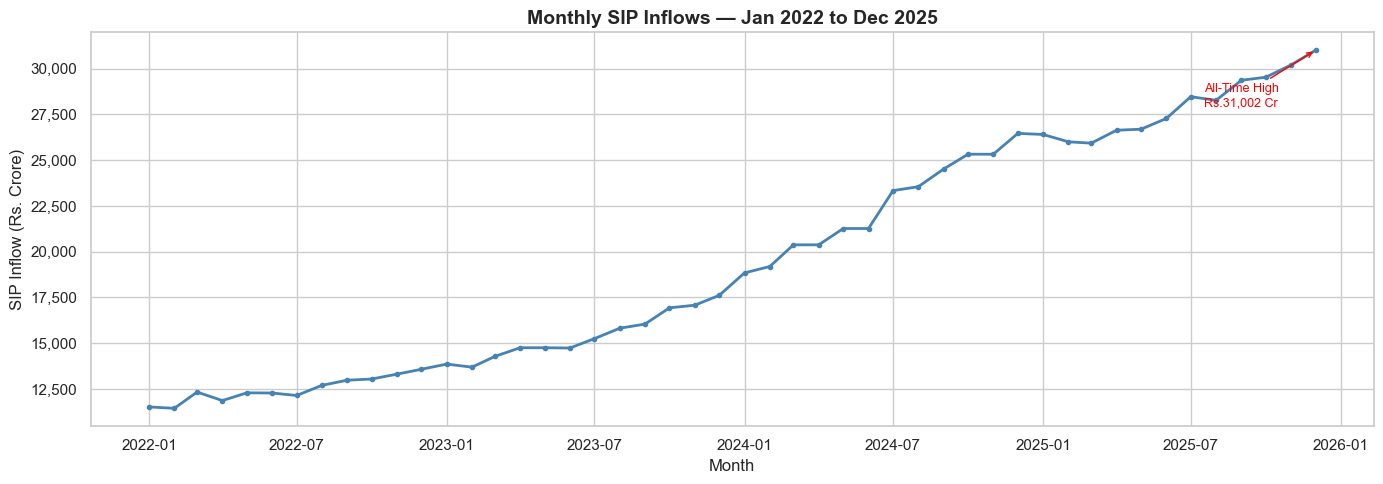

Chart 3 saved


In [15]:
sip["month_dt"] = pd.to_datetime(sip["month"])

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(sip["month_dt"], sip["sip_inflow_crore"], color="steelblue", linewidth=2, marker="o", markersize=3)

# mark the all time high
max_idx = sip["sip_inflow_crore"].idxmax()
ax.annotate(
    f"All-Time High\nRs.{sip.loc[max_idx,'sip_inflow_crore']:,.0f} Cr",
    xy=(sip.loc[max_idx,"month_dt"], sip.loc[max_idx,"sip_inflow_crore"]),
    xytext=(-80, -40), textcoords="offset points",
    arrowprops=dict(arrowstyle="->", color="red"),
    fontsize=9, color="red"
)

ax.set_title("Monthly SIP Inflows — Jan 2022 to Dec 2025", fontsize=14, fontweight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("SIP Inflow (Rs. Crore)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.tight_layout()
plt.savefig(CHARTS / "chart_03_sip_inflows.png", dpi=150)
plt.show()
print("Chart 3 saved")

Category inflow heatmap

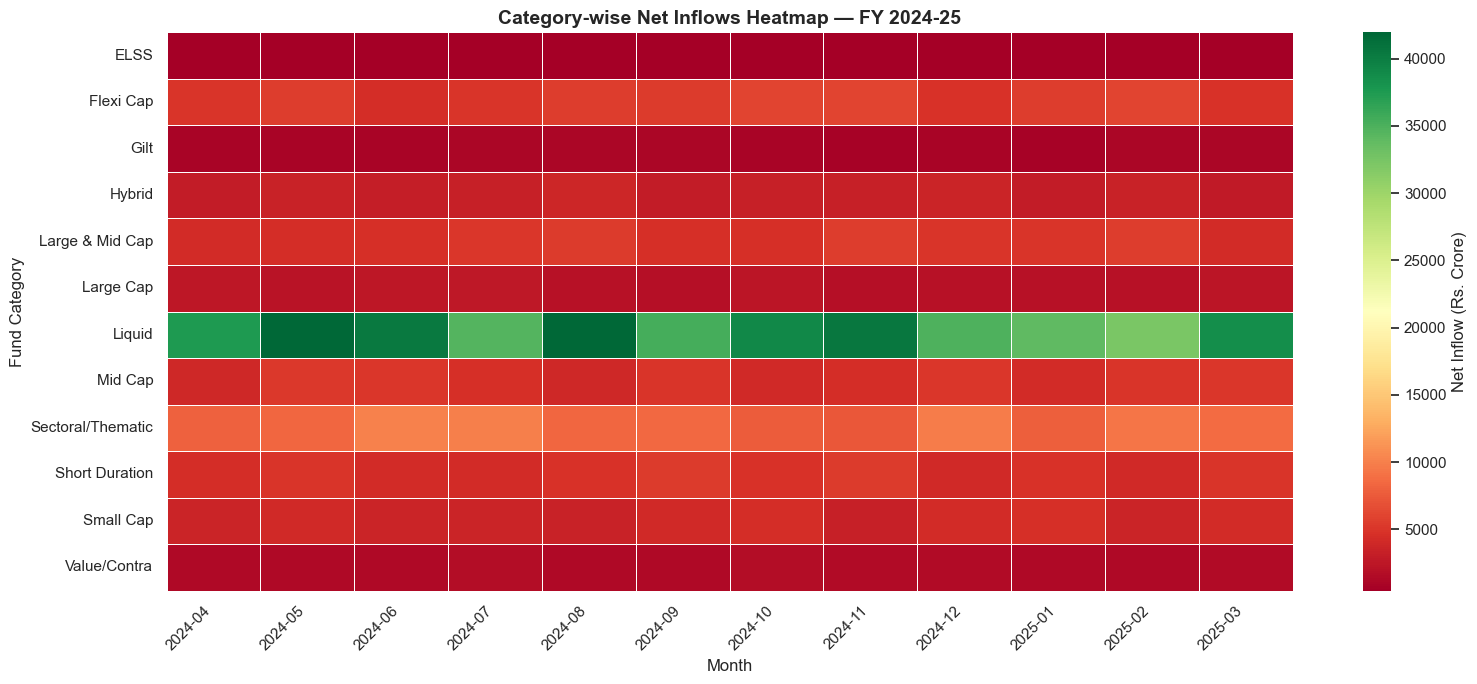

In [17]:
cat_pivot = cat.pivot(index="category", columns="month", values="net_inflow_crore")

plt.figure(figsize=(16, 7))
sns.heatmap(
    cat_pivot,
    cmap="RdYlGn",
    linewidths=0.4,
    annot=False,
    fmt=".0f",
    cbar_kws={"label": "Net Inflow (Rs. Crore)"}
)
plt.title("Category-wise Net Inflows Heatmap — FY 2024-25", fontsize=14, fontweight="bold")
plt.xlabel("Month")
plt.ylabel("Fund Category")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(CHARTS / "chart_04_category_heatmap.png", dpi=150)
plt.show()


Investor Demographics

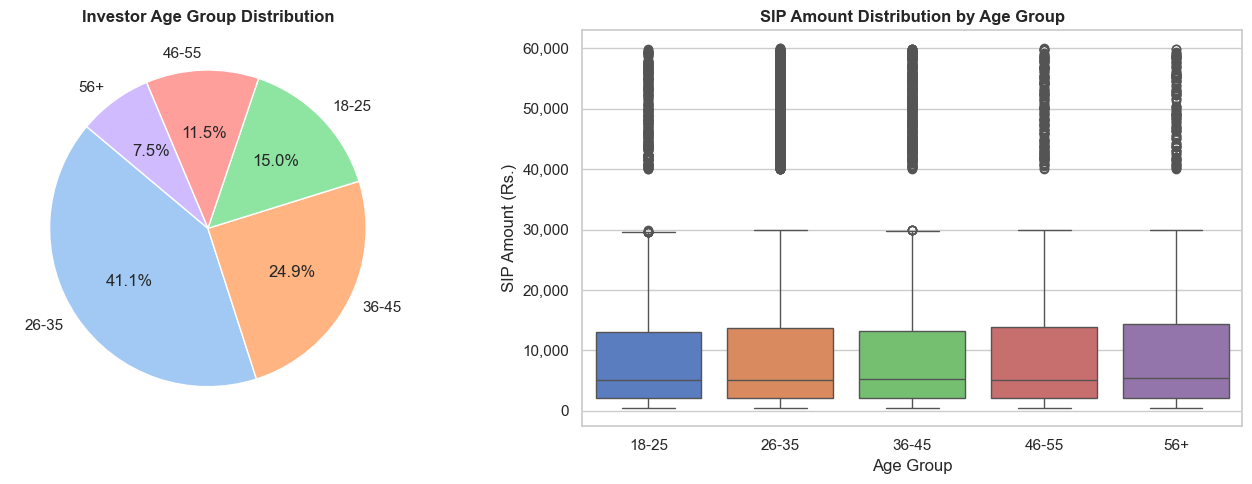

Charts 5 & 6 saved


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# pie chart — age group distribution
age_counts = tx["age_group"].value_counts()
axes[0].pie(age_counts, labels=age_counts.index, autopct="%1.1f%%",
            startangle=140, colors=sns.color_palette("pastel"))
axes[0].set_title("Investor Age Group Distribution", fontweight="bold")

# box plot — SIP amount by age group
sip_tx = tx[tx["transaction_type"] == "Sip"]
sns.boxplot(data=sip_tx, x="age_group", y="amount_inr", ax=axes[1],
            order=["18-25","26-35","36-45","46-55","56+"],
            palette="muted")
axes[1].set_title("SIP Amount Distribution by Age Group", fontweight="bold")
axes[1].set_xlabel("Age Group")
axes[1].set_ylabel("SIP Amount (Rs.)")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

plt.tight_layout()
plt.savefig(CHARTS / "chart_05_06_demographics.png", dpi=150)
plt.show()
print("Charts 5 & 6 saved")

Geographic distribution

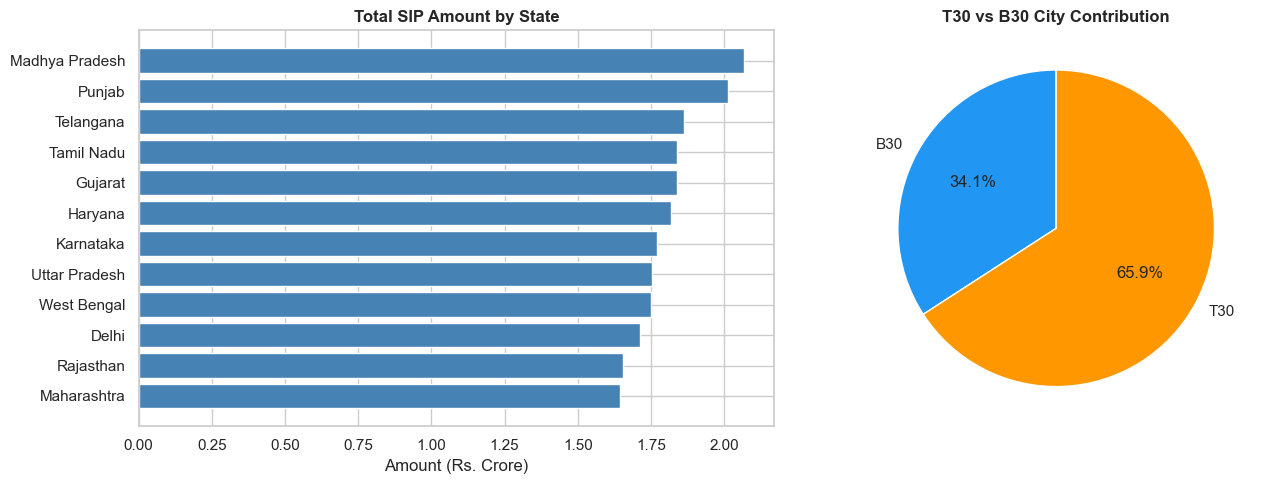

Chart 7 saved


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

state_sip = (tx[tx["transaction_type"]=="Sip"]
             .groupby("state")["amount_inr"]
             .sum()
             .sort_values()
             / 1e7)  # convert to crore

axes[0].barh(state_sip.index, state_sip.values, color="steelblue")
axes[0].set_title("Total SIP Amount by State", fontweight="bold")
axes[0].set_xlabel("Amount (Rs. Crore)")

tier = tx.groupby("city_tier")["amount_inr"].sum()
axes[1].pie(tier, labels=tier.index, autopct="%1.1f%%",
            colors=["#2196F3","#FF9800"], startangle=90)
axes[1].set_title("T30 vs B30 City Contribution", fontweight="bold")

plt.tight_layout()
plt.savefig(CHARTS / "chart_07_geo_distribution.png", dpi=150)
plt.show()
print("Chart 7 saved")

In [ ]:
Correlation mat

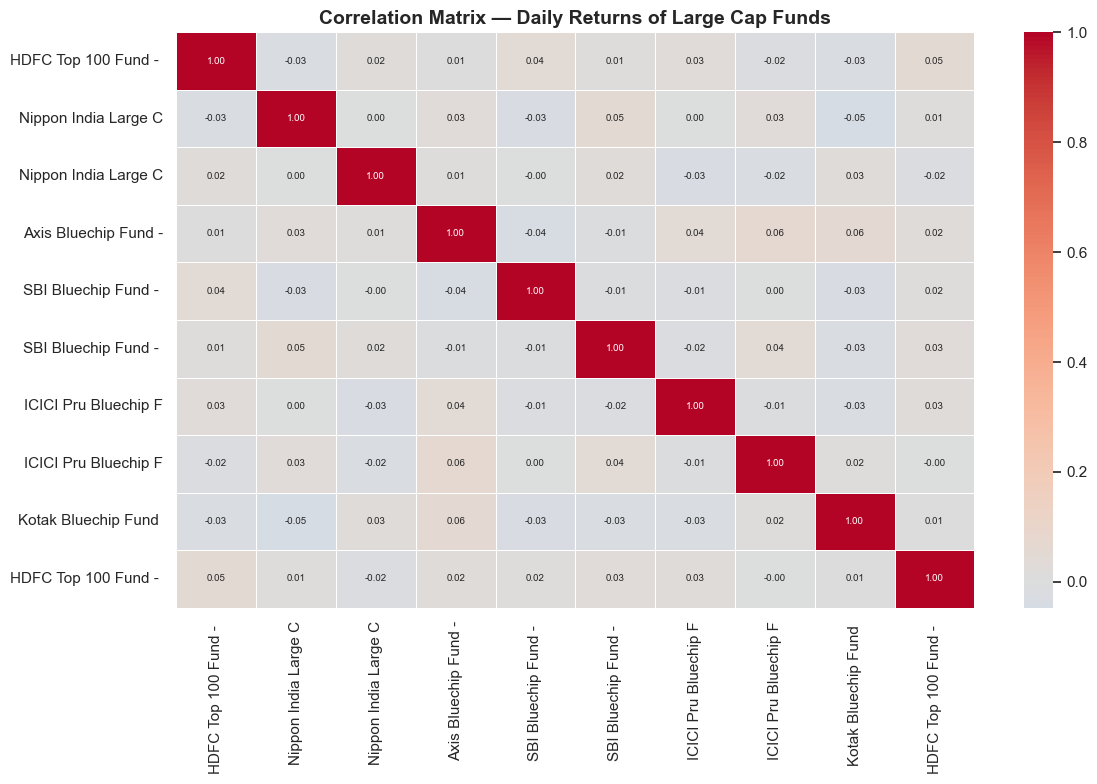

Chart 9 saved


In [20]:
# computing daily returns for 10 large cap funds
large_cap_codes = fm[fm["sub_category"]=="Large Cap"]["amfi_code"].tolist()[:10]
nav_lc = nav[nav["amfi_code"].isin(large_cap_codes)].copy()
nav_lc["daily_return"] = nav_lc.groupby("amfi_code")["nav"].pct_change()

# pivot to wide format
corr_pivot = nav_lc.pivot(index="date", columns="amfi_code", values="daily_return")
corr_matrix = corr_pivot.corr()

# rename columns to short names for readability
code_to_name = fm.set_index("amfi_code")["scheme_name"].str[:20].to_dict()
corr_matrix.columns = [code_to_name.get(c, c) for c in corr_matrix.columns]
corr_matrix.index   = corr_matrix.columns

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.5, annot_kws={"size": 7})
plt.title("Correlation Matrix — Daily Returns of Large Cap Funds", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(CHARTS / "chart_09_correlation_matrix.png", dpi=150)
plt.show()
print("Chart 9 saved")

Sector allocation share

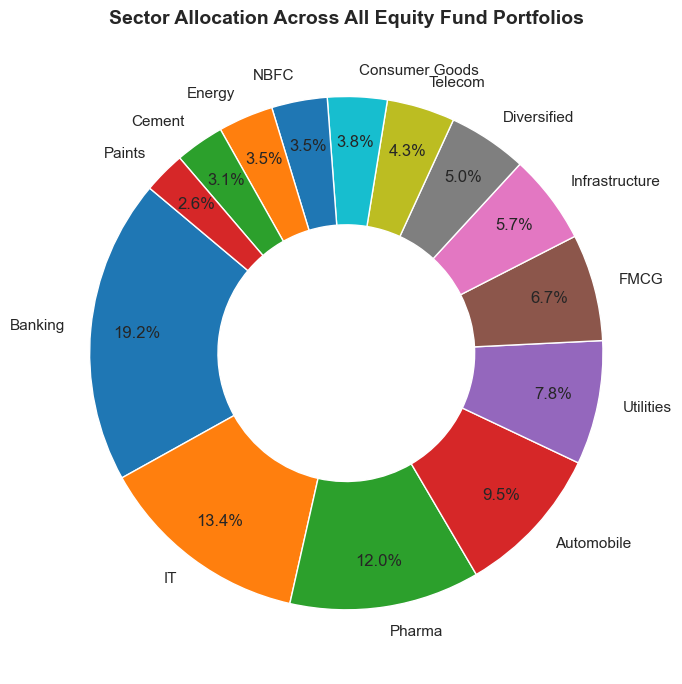

Chart 10 saved


In [21]:
sector_weights = hold.groupby("sector")["weight_pct"].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
wedges, texts, autotexts = ax.pie(
    sector_weights,
    labels=sector_weights.index,
    autopct="%1.1f%%",
    startangle=140,
    pctdistance=0.82,
    colors=sns.color_palette("tab10", len(sector_weights)),
    wedgeprops=dict(width=0.5)
)
ax.set_title("Sector Allocation Across All Equity Fund Portfolios", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(CHARTS / "chart_10_sector_allocation.png", dpi=150)
plt.show()
print("Chart 10 saved")

Risk vs return

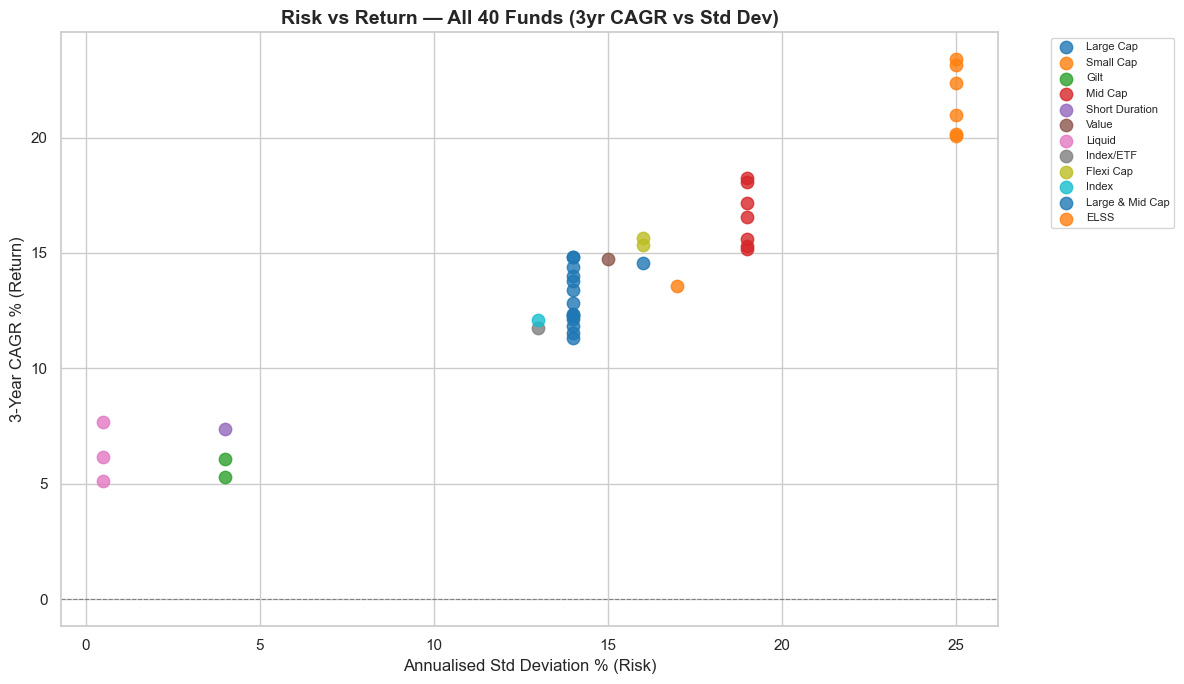

In [22]:
perf_merged = perf.merge(fm[["amfi_code","scheme_name","sub_category"]], on="amfi_code", how="left")

plt.figure(figsize=(12, 7))
categories = perf_merged["sub_category"].unique()
colors = sns.color_palette("tab10", len(categories))

for cat_name, color in zip(categories, colors):
    subset = perf_merged[perf_merged["sub_category"] == cat_name]
    plt.scatter(subset["std_dev_ann_pct"], subset["return_3yr_pct"],
                label=cat_name, color=color, s=80, alpha=0.8)

plt.axhline(y=0, color="gray", linestyle="--", linewidth=0.8)
plt.title("Risk vs Return — All 40 Funds (3yr CAGR vs Std Dev)", fontsize=14, fontweight="bold")
plt.xlabel("Annualised Std Deviation % (Risk)")
plt.ylabel("3-Year CAGR % (Return)")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.savefig(CHARTS / "chart_11_risk_return.png", dpi=150)
plt.show()


In [ ]:
Transact volume vs time

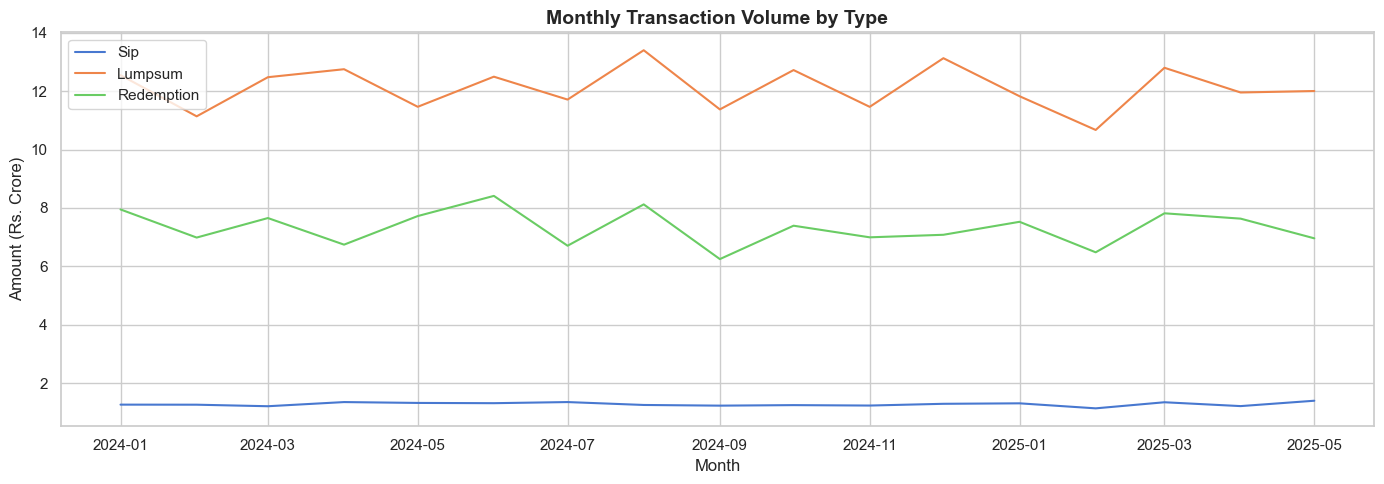

In [ ]:
tx["month"] = tx["transaction_date"].dt.to_period("M").astype(str)
monthly_vol = tx.groupby(["month","transaction_type"])["amount_inr"].sum().reset_index()
monthly_vol["amount_crore"] = monthly_vol["amount_inr"] / 1e7
monthly_vol["month_dt"] = pd.to_datetime(monthly_vol["month"])

fig, ax = plt.subplots(figsize=(14, 5))
for tx_type in ["Sip","Lumpsum","Redemption"]:
    subset = monthly_vol[monthly_vol["transaction_type"] == tx_type]
    ax.plot(subset["month_dt"], subset["amount_crore"], label=tx_type, linewidth=1.5)

ax.set_title("Monthly Transaction Volume by Type", fontsize=14, fontweight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("Amount (Rs. Crore)")
ax.legend()
plt.tight_layout()
plt.savefig(CHARTS / "chart_12_transaction_volume.png", dpi=150)
plt.show()

Sharpe ratio bar chart

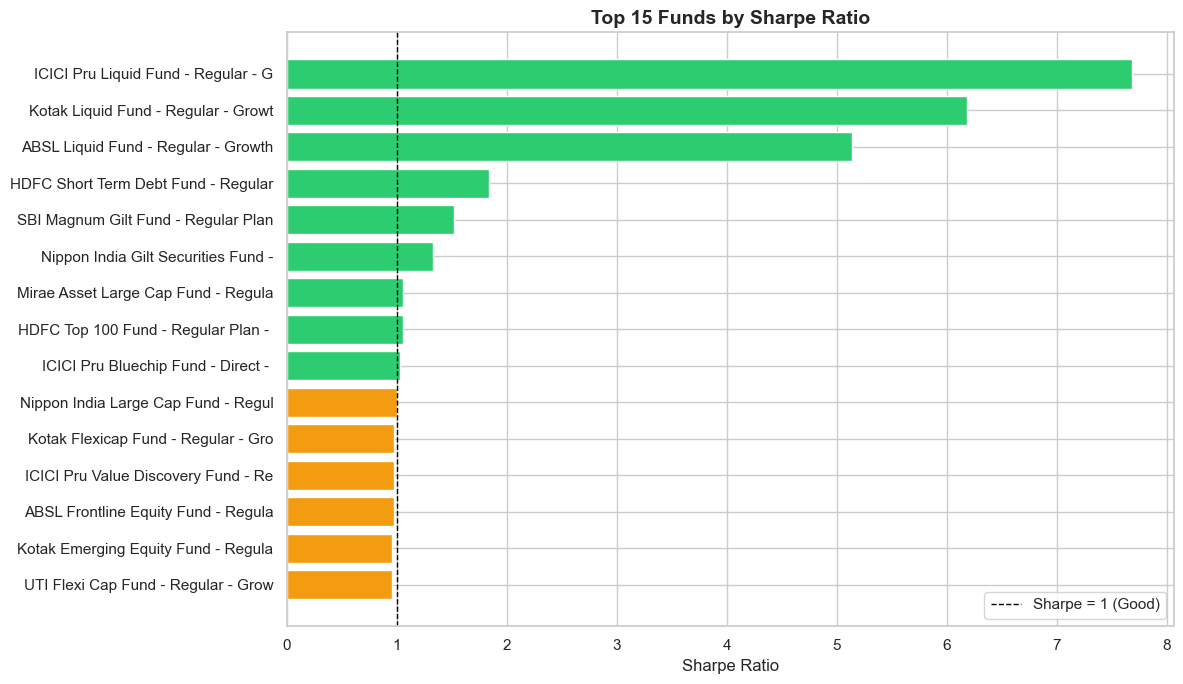

In [39]:
perf_sorted = perf.merge(fm[["amfi_code","scheme_name"]], on="amfi_code").sort_values("sharpe_ratio", ascending=True).tail(15)

plt.figure(figsize=(12, 7))
colors = ["#2ecc71" if x > 1 else "#e74c3c" if x < 0 else "#f39c12"
          for x in perf_sorted["sharpe_ratio"]]
plt.barh(perf_sorted["scheme_name_x"].str[:35], perf_sorted["sharpe_ratio"], color=colors)
plt.axvline(x=1, color="black", linestyle="--", linewidth=1, label="Sharpe = 1 (Good)")
plt.title("Top 15 Funds by Sharpe Ratio", fontsize=14, fontweight="bold")
plt.xlabel("Sharpe Ratio")
plt.legend()
plt.tight_layout()
plt.savefig(CHARTS / "chart_13_sharpe_ratio.png", dpi=150)
plt.show()


Payment mode distribution

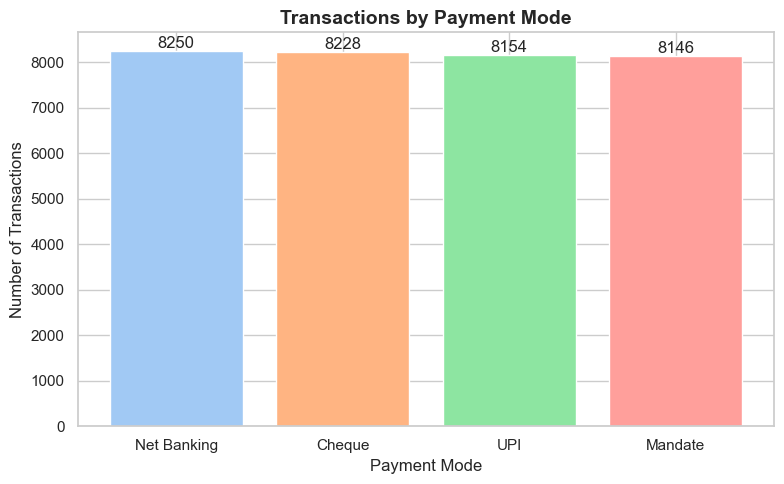

Chart 14 saved


In [40]:
pay = tx["payment_mode"].value_counts()

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(pay.index, pay.values,
              color=sns.color_palette("pastel", len(pay)))
ax.bar_label(bars, fmt="%d")
ax.set_title("Transactions by Payment Mode", fontsize=14, fontweight="bold")
ax.set_xlabel("Payment Mode")
ax.set_ylabel("Number of Transactions")
plt.tight_layout()
plt.savefig(CHARTS / "chart_14_payment_mode.png", dpi=150)
plt.show()
print("Chart 14 saved")

Gender wise avg investment 

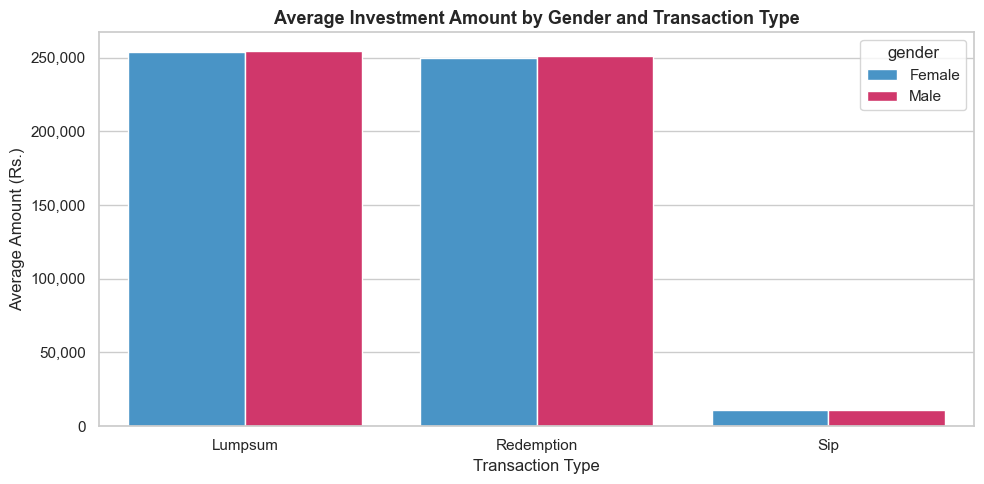

Chart 15 saved


In [41]:
gender_avg = tx.groupby(["gender","transaction_type"])["amount_inr"].mean().reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(data=gender_avg, x="transaction_type", y="amount_inr",
            hue="gender", palette=["#3498db","#e91e63"])
plt.title("Average Investment Amount by Gender and Transaction Type", fontsize=13, fontweight="bold")
plt.xlabel("Transaction Type")
plt.ylabel("Average Amount (Rs.)")
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.tight_layout()
plt.savefig(CHARTS / "chart_15_gender_investment.png", dpi=150)
plt.show()
print("Chart 15 saved")

##EDA Findings

1. SIP growth is consistent — Monthly SIP inflows grew steadily from ~Rs.11,000 Cr in Jan 2022 
   to an all-time high of Rs.31,002 Cr in Dec 2025, showing strong retail participation growth.

2. SBI dominates AUM — SBI Mutual Fund leads with Rs.12.5 lakh crore AUM, nearly 2x 
   the second-placed ICICI Prudential at Rs.10.74 lakh crore.

3. Small Cap funds are most volatile — The NAV trend chart shows Small Cap funds 
   have the steepest rises and sharpest corrections compared to Large Cap and Debt funds.

4. Folio count nearly doubled — Industry folios grew from 13.26 crore to 26.12 crore 
   in under 4 years, driven almost entirely by equity fund growth.

5. 26-35 age group dominates SIP investing — The largest share of SIP transactions 
   comes from investors aged 26-35, suggesting young salaried professionals are the 
   core mutual fund customer.

6. T30 cities contribute ~65% of total investment — Top 30 cities account for the 
   majority of transaction volume but B30 cities are growing, showing financial inclusion.

7. Financials and IT dominate equity portfolios — Across all equity funds, 
   Financials and IT sectors together account for over 45% of total portfolio weight.

8. Large Cap funds show high correlation — The correlation matrix shows returns 
   of Large Cap funds are highly correlated (0.85+), meaning they tend to move together.

9. UPI is the dominant payment mode — Over 50% of SIP transactions are done via UPI, 
   reflecting India's digital payment revolution.

10. Sharpe ratios vary widely — Some funds have Sharpe ratios above 1.5 (excellent) 
    while others are negative, showing significant quality differences even within the 
    same category.